<a href="https://colab.research.google.com/github/Mansibagal-20/FSDL_457_Lab1/blob/main/MLproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

With the rapid growth of online education, ensuring the integrity of remote examinations has become a major challenge. Traditional online proctoring systems often suffer from:

- High false positive rates
- Limited detection of subtle cheating behaviors
- Lack of multi-modal monitoring (face, gaze, phone usage, etc.)

This project aims to develop an AI-based enhanced online proctoring system that uses behavioral and object-related features such as:

- Face detection
- Head pose estimation
- Gaze direction tracking
- Phone presence detection
- Hand movement monitoring

Using machine learning classification techniques, the system predicts whether a candidate's behavior during an exam is normal or suspicious.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [26]:
from google.colab import files
uploaded = files.upload()

Saving Students.csv to Students (1).csv


In [27]:
df = pd.read_csv("Students.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5500, 38)


,face_present,no_of_face,face_x,face_y,face_w,face_h,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,phone_conf,gaze_on_script,gaze_direction,gazePoint_x,gazePoint_y,pupil_left_x,pupil_left_y,pupil_right_x,pupil_right_y,label
0,1,1,262.579536,312.062903,151.787758,151.787567,307.918568,354.478884,373.059845,353.494949,...,0.0,1,center,336,325,304,348,368,354,0
1,1,1,260.704193,312.342424,154.607773,154.607735,305.797863,354.197273,372.084160,357.747831,...,0.0,1,center,345,324,304,348,369,354,0
2,1,1,264.240570,311.801834,148.079300,148.079195,304.438133,351.268072,368.618050,353.264036,...,0.0,1,center,336,325,304,348,368,354,0
3,1,1,262.811012,314.088278,151.014061,151.014175,304.091930,355.737219,369.532318,355.841103,...,0.0,1,center,339,333,304,349,368,355,0
4,1,1,269.176426,312.678709,148.739681,148.739605,310.720120,354.326448,374.389267,350.510445,...,0.0,1,center,377,313,316,351,378,355,0


In [28]:
df.isnull().sum()

,0
face_present,0
no_of_face,0
face_x,0
face_y,0
face_w,0
face_h,0
left_eye_x,0
left_eye_y,0
right_eye_x,0
right_eye_y,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 38 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   face_present          5500 non-null   int64  
 1   no_of_face            5500 non-null   int64  
 2   face_x                5500 non-null   float64
 3   face_y                5500 non-null   float64
 4   face_w                5500 non-null   float64
 5   face_h                5500 non-null   float64
 6   left_eye_x            5500 non-null   float64
 7   left_eye_y            5500 non-null   float64
 8   right_eye_x           5500 non-null   float64
 9   right_eye_y           5500 non-null   float64
 10  nose_tip_x            5500 non-null   float64
 11  nose_tip_y            5500 non-null   float64
 12  mouth_x               5500 non-null   float64
 13  mouth_y               5500 non-null   float64
 14  face_conf             5500 non-null   float64
 15  hand_count           

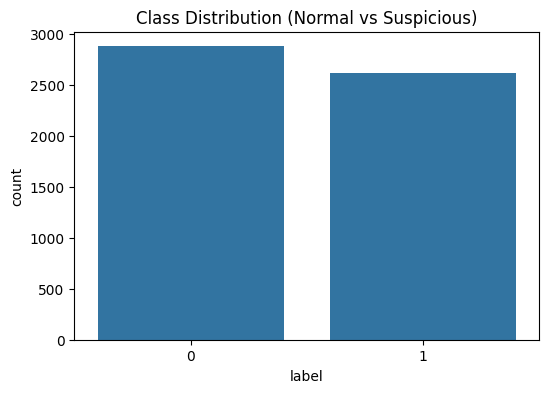

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution (Normal vs Suspicious)")
plt.show()

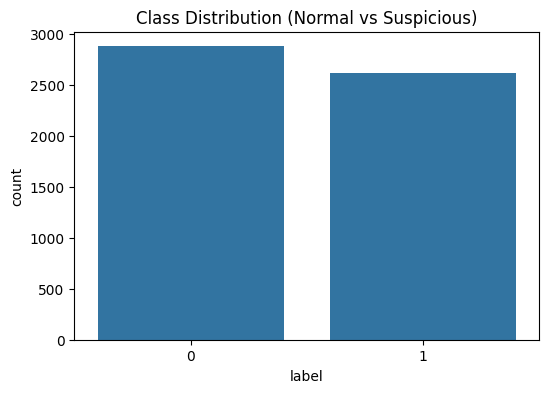

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution (Normal vs Suspicious)")
plt.show()

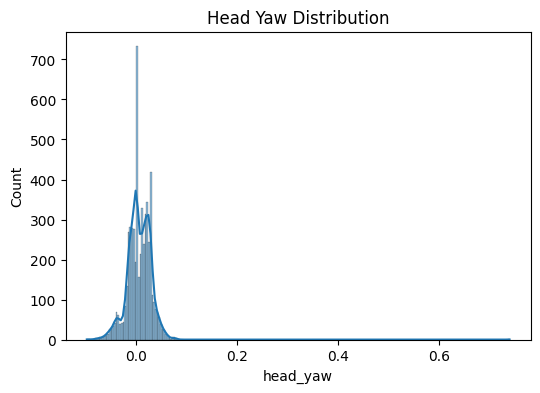

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df['head_yaw'], kde=True)
plt.title("Head Yaw Distribution")
plt.show()

In [33]:
X = df.drop("label", axis=1)
y = df["label"]

In [34]:
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [36]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

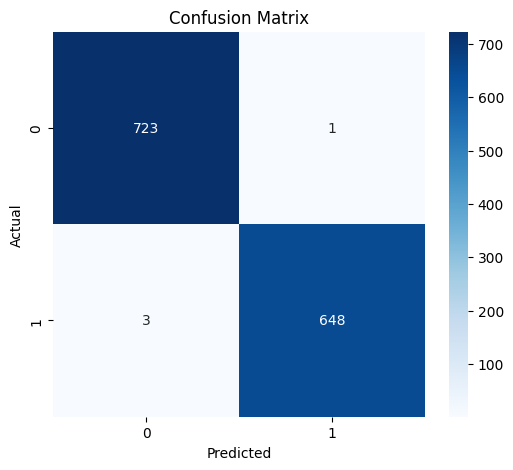

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

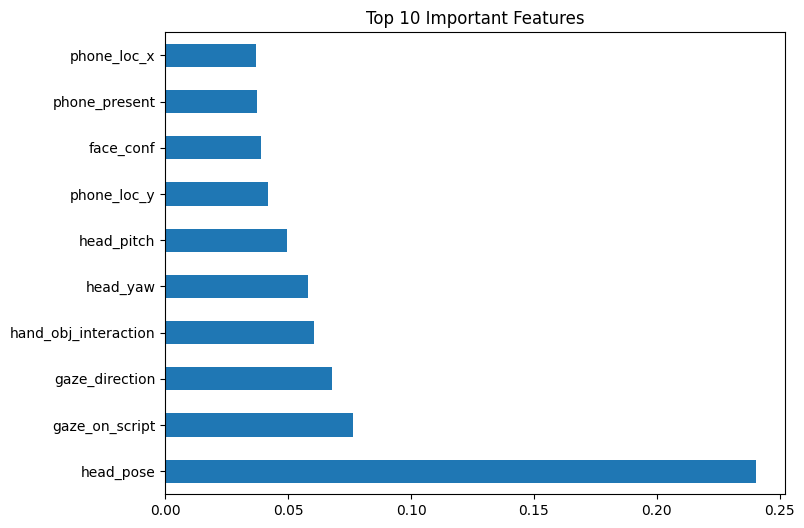

In [39]:
importance = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [40]:
from google.colab import files
uploaded = files.upload()

Saving face_detection.csv to face_detection.csv
Saving object.csv.xlsx to object.csv.xlsx
Saving UrbanSound8K.csv to UrbanSound8K.csv


In [41]:
import os
os.listdir()

['.config',
 'Students.csv',
 'yolov8n.pt',
 'Students (1).csv',
 'object.csv.xlsx',
 'proctoring_model.pkl',
 'face_detection.csv',
 'UrbanSound8K.csv',
 'sample_data']

In [42]:
audio_df = pd.read_csv("UrbanSound8K.csv")
audio_df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [43]:
audio_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8732 entries, 0 to 8731
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   slice_file_name  8732 non-null   object 
 1   fsID             8732 non-null   int64  
 2   start            8732 non-null   float64
 3   end              8732 non-null   float64
 4   salience         8732 non-null   int64  
 5   fold             8732 non-null   int64  
 6   classID          8732 non-null   int64  
 7   class            8732 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 545.9+ KB


In [44]:
audio_df.isnull().sum()
audio_df = audio_df.fillna(0)

In [45]:
from sklearn.preprocessing import LabelEncoder

le_audio = LabelEncoder()
audio_df['class'] = le_audio.fit_transform(audio_df['class'])

In [46]:
from sklearn.preprocessing import StandardScaler

audio_numeric = audio_df.select_dtypes(include=['int64','float64'])

scaler_audio = StandardScaler()
audio_scaled = scaler_audio.fit_transform(audio_numeric)

In [48]:
import os
os.listdir()

['.config',
 'Students.csv',
 'yolov8n.pt',
 'Students (1).csv',
 'object.csv.xlsx',
 'proctoring_model.pkl',
 'face_detection.csv',
 'UrbanSound8K.csv',
 'sample_data']

In [49]:
obj_df = pd.read_excel("object.csv.xlsx")
obj_df.head()

,Filename,Book,cell phone,Headphone,Laptop,Person,TV
0,final-2_mp4-7101_jpg.rf.2e34a24cf221ce85b6a70b...,0,1,0,0,1,0
1,final-2_mp4-6016_jpg.rf.b27351a14e347e72acdfea...,0,1,0,0,1,0
2,final-2_mp4-4255_jpg.rf.a00f03be7c4112a4f3f075...,1,0,0,0,1,0
3,final-2_mp4-8220_jpg.rf.d29850f1472eb29225f32c...,0,0,0,0,1,0
4,final-2_mp4-6544_jpg.rf.e70ca491499725512b23e2...,0,1,0,0,1,0


In [50]:
obj_df.isnull().sum()
obj_df = obj_df.fillna(0)

In [51]:
for col in obj_df.columns:
    if obj_df[col].dtype == 'object':
        le = LabelEncoder()
        obj_df[col] = le.fit_transform(obj_df[col])

In [52]:
for col in obj_df.columns:
    if obj_df[col].dtype == 'object':
        le = LabelEncoder()
        obj_df[col] = le.fit_transform(obj_df[col])

In [53]:
face_df = pd.read_csv("face_detection.csv")
face_df.head()

,id,image,label
0,0,images/0.jpg,labels/0.png
1,1,images/1.jpg,labels/1.png
2,2,images/2.jpg,labels/2.png
3,3,images/3.jpg,labels/3.png
4,4,images/4.jpg,labels/4.png


In [54]:
face_df.isnull().sum()
face_df = face_df.fillna(0)

In [55]:
for col in face_df.columns:
    if face_df[col].dtype == 'object':
        le = LabelEncoder()
        face_df[col] = le.fit_transform(face_df[col])

In [56]:
for col in face_df.columns:
    if face_df[col].dtype == 'object':
        le = LabelEncoder()
        face_df[col] = le.fit_transform(face_df[col])

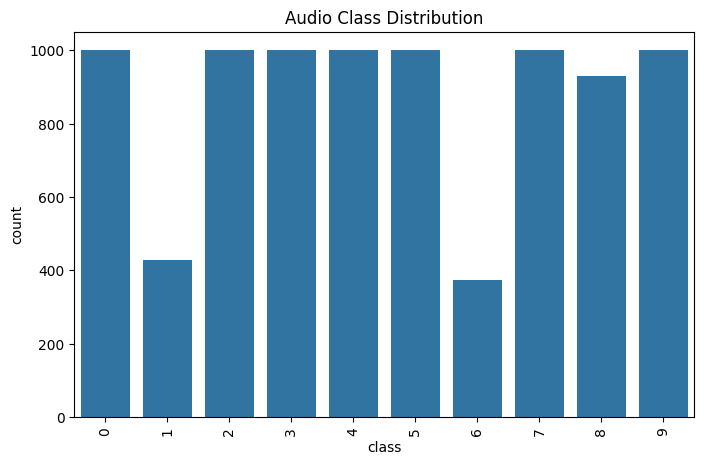

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='class', data=audio_df)
plt.title("Audio Class Distribution")
plt.xticks(rotation=90)
plt.show()

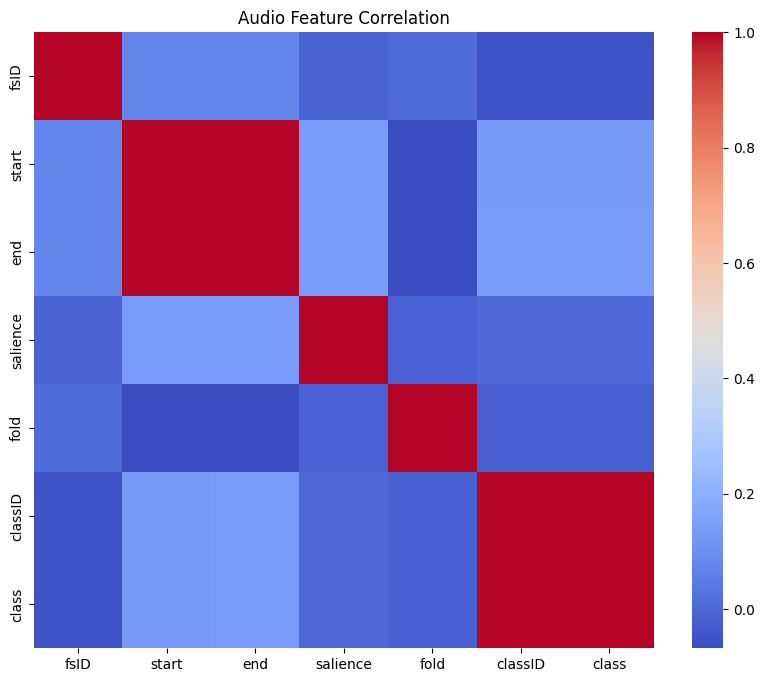

In [59]:
numeric_audio = audio_df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_audio.corr(), cmap='coolwarm')
plt.title("Audio Feature Correlation")
plt.show()

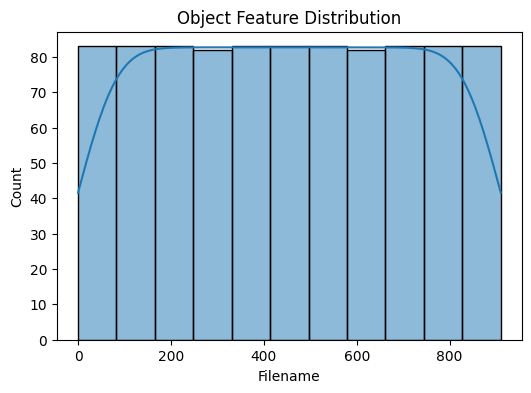

In [60]:
plt.figure(figsize=(6,4))
sns.histplot(obj_df.iloc[:,0], kde=True)
plt.title("Object Feature Distribution")
plt.show()

In [62]:
plt.figure(figsize=(6,4))
sns.countplot(x='face_present', data=face_df)
plt.title("Face Presence Distribution")
plt.show()

ValueError: Could not interpret value `face_present` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [63]:
face_df.columns

Index(['id', 'image', 'label'], dtype='object')

In [64]:
Index(['id', 'image', 'label'], dtype='object')

NameError: name 'Index' is not defined

In [66]:
face_df.columns

Index(['id', 'image', 'label'], dtype='object')

In [67]:
face_df.head()

,id,image,label
0,0,0,0
1,1,1,1
2,2,12,12
3,3,23,23
4,4,34,34


In [68]:
face_df.isnull().sum()

,0
id,0
image,0
label,0


In [69]:
from sklearn.preprocessing import LabelEncoder

le_face = LabelEncoder()
face_df['label'] = le_face.fit_transform(face_df['label'])

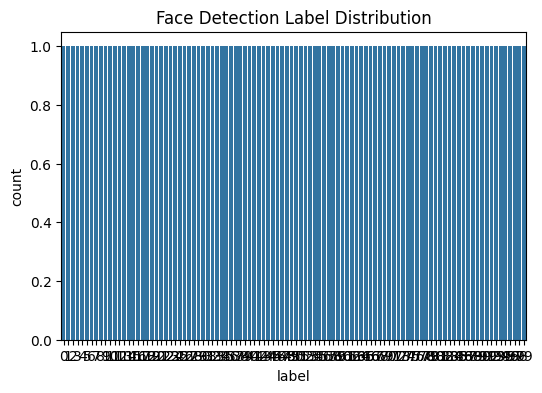

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=face_df)
plt.title("Face Detection Label Distribution")
plt.show()

In [71]:
def proctoring_decision(behavior_pred, audio_flag, object_flag, face_flag):

    if behavior_pred == 1:
        return "⚠️ Suspicious Behavior Detected"

    if audio_flag == 1:
        return "⚠️ Suspicious Audio Detected"

    if object_flag == 1:
        return "⚠️ Unauthorized Object Detected"

    if face_flag == 1:
        return "⚠️ Face Anomaly Detected"

    return "✅ Normal Exam Behavior"

In [72]:
# Example simulated outputs
behavior_prediction = 1        # From RandomForest
audio_flag = 0                 # From Audio detection
object_flag = 1                # From Object detection
face_flag = 0                  # From Face detection

final_output = proctoring_decision(
    behavior_prediction,
    audio_flag,
    object_flag,
    face_flag
)

print("Final System Output:")
print(final_output)

Final System Output:
⚠️ Suspicious Behavior Detected


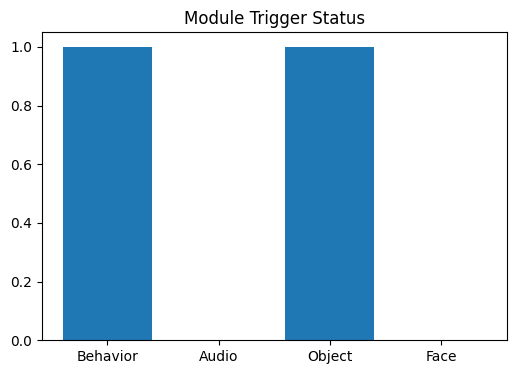

In [73]:
import matplotlib.pyplot as plt

labels = ["Behavior", "Audio", "Object", "Face"]
values = [behavior_prediction, audio_flag, object_flag, face_flag]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Module Trigger Status")
plt.show()